<a href="https://colab.research.google.com/github/AmishAwasthi27/synent-task9-End-to-End-Data-Science-Project-Amish-Awasthi/blob/main/Copy_of_Synent_Task3_Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv.zip to netflix_titles.csv.zip


## loading the dataset and cleaning it

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv.zip')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## checking data types and null values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### as per this result , we either want to fill the missing data or drop it
### 1) director = missing count is 2634 so it would be good to fill using unknown or not given
### 2) cast = missing count is 825 , so it would be good to fill the using unkown or not given
### 3) cast = same as above
### 4) country = same as above
### 5) date_added = we can drop this as it has only 10 as missing count
### 6) rating = we would fill this by replacing with unknown or manually looking up
### 7) duration = manually inspect the 3 rows and add the rating

In [7]:
# 1. Fill high-missing categorical columns with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

/tmp/ipykernel_433/788959697.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_433/788959697.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [8]:
# 2. Fill small categorical missing values or drop minimal missing rows
df['rating'].fillna('Unknown', inplace=True)

/tmp/ipykernel_433/2765143561.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna('Unknown', inplace=True)


## viewing the rows where duration is missing

In [9]:
df[df['duration'].isnull()][['title', 'rating', 'duration']]

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


## since the duration is stored in the rating , so we can transfer the string from rating into duration and then update rating

In [10]:
df['duration'] = df['duration'].fillna(df['rating'])

## now we will set the rating for these specific rows to 'Unavailable' or 'Not Rated'
(since the original rating column held the duration value)

In [11]:
df.loc[df['duration'] == df['rating'], 'rating'] = 'Unavailable'

## checking if the changes are upadted or not

In [12]:
df['duration'].isnull().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


## now dropping the date_added missing data

In [ ]:
df.dropna(subset=['date_added'], inplace=True)

In [14]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


## thats how all the missing values are gone and nothing is null

## std way to format the date_added column using pd.to_datetime() and extract the month, month name, and year for your exploratory data analysis (EDA).

In [15]:
# 1. Strip whitespace and convert 'date_added' to datetime objects
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

In [16]:
# 2. Extract Year, Month Number, and Month Name into new columns
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month
df['added_month_name'] = df['date_added'].dt.month_name()

In [17]:
# 3. Verify the changes and check data types
df[['date_added', 'added_year', 'added_month', 'added_month_name']].head()

,date_added,added_year,added_month,added_month_name
0,2021-09-25,2021.0,9.0,September
1,2021-09-24,2021.0,9.0,September
2,2021-09-24,2021.0,9.0,September
3,2021-09-24,2021.0,9.0,September
4,2021-09-24,2021.0,9.0,September


# Trend Analysis


## now , content addition trends over time

<Axes: title={'center': 'Content Added Per Year'}, xlabel='added_year'>

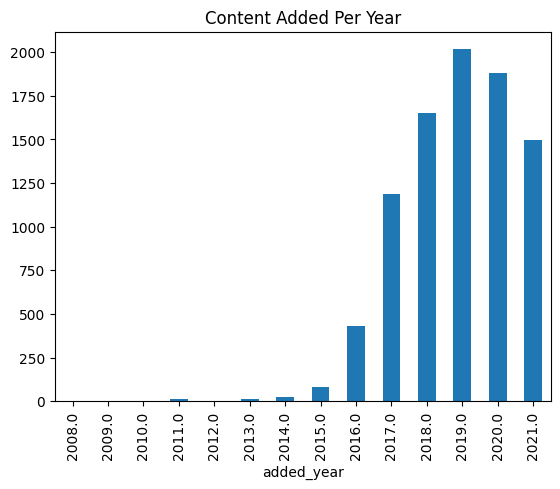

In [18]:
df['added_year'].value_counts().sort_index().plot(kind='bar', title='Content Added Per Year')

## best month for content release

<Axes: title={'center': 'Content Added by Month'}, xlabel='added_month_name'>

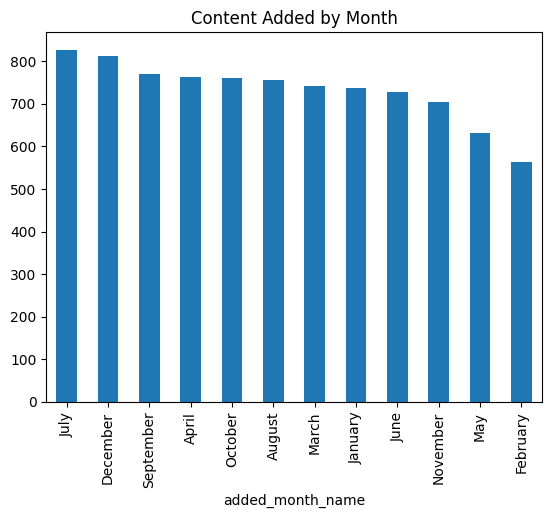

In [19]:
df['added_month_name'].value_counts().plot(kind='bar', title='Content Added by Month')

## top content producing countries

/tmp/ipykernel_433/2461066574.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


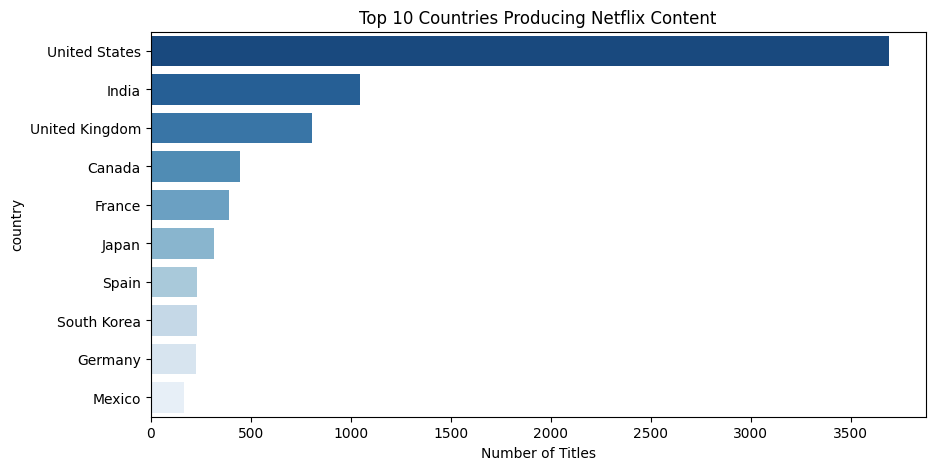

In [20]:
# Unnest comma-separated countries to count individually
top_countries = df['country'].str.split(', ').explode().value_counts()
top_countries = top_countries[top_countries.index != 'Unknown'].head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.show()

## movies vs tv shows ratio

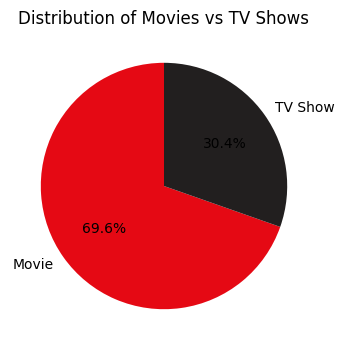

In [21]:
plt.figure(figsize=(6, 4))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#e50914', '#221f1f'], startangle=90)
plt.title('Distribution of Movies vs TV Shows')
plt.ylabel('')
plt.show()

## Rating Distribution by Content Type

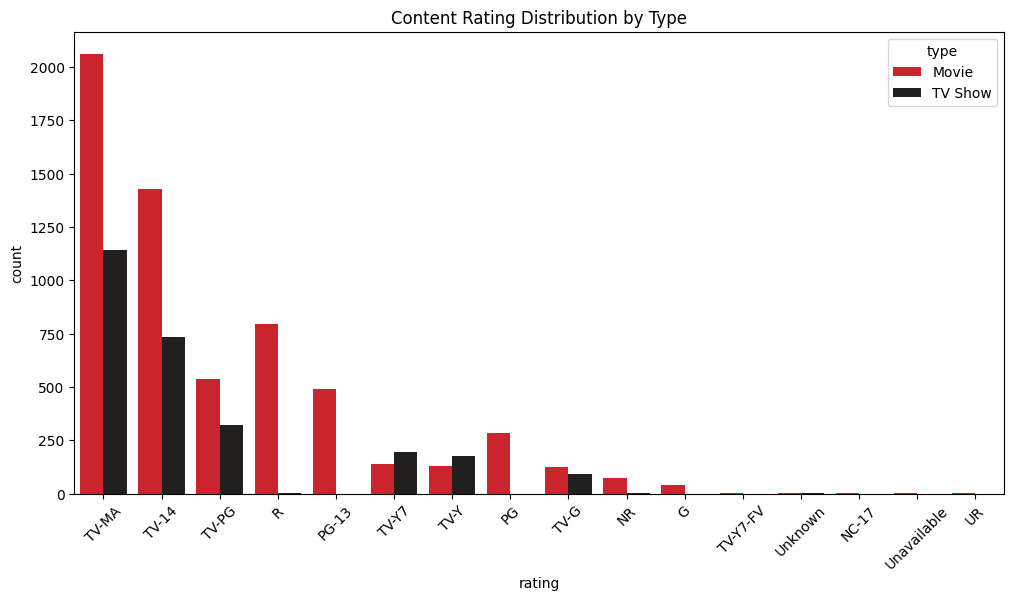

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette=['#e50914', '#221f1f'])
plt.title('Content Rating Distribution by Type')
plt.xticks(rotation=45)
plt.show()

## Top Genres (listed_in)

/tmp/ipykernel_433/208647317.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genres.values, y=genres.index, palette='Reds_r')


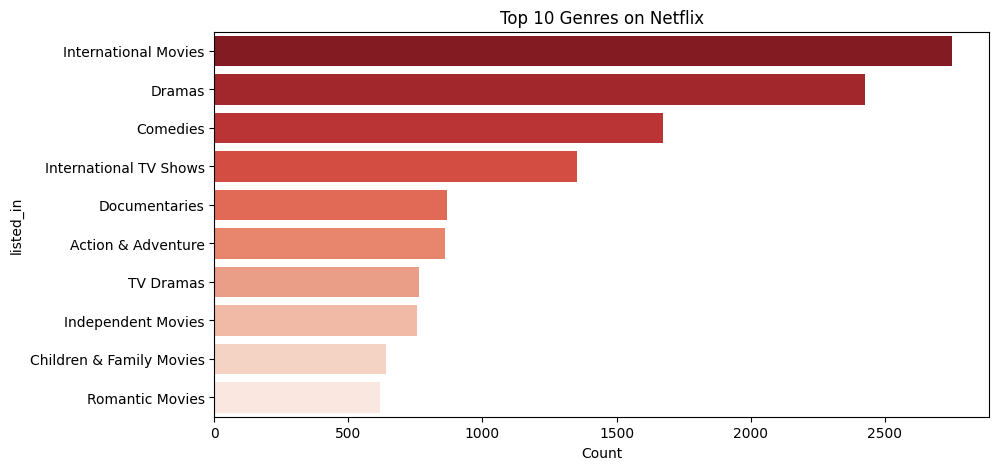

In [23]:
# Unnest genres separated by commas
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=genres.values, y=genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.show()

## Movie Duration Distribution

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_433/3227121458.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)


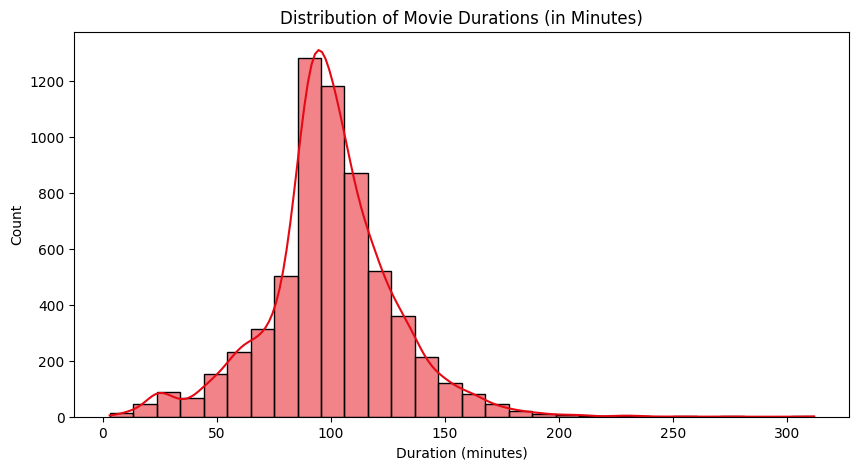

In [24]:
# Filter movies and convert duration to numeric minutes
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_min'], bins=30, kde=True, color='#e50914')
plt.title('Distribution of Movie Durations (in Minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

## Gap Between Release Year and Added Year

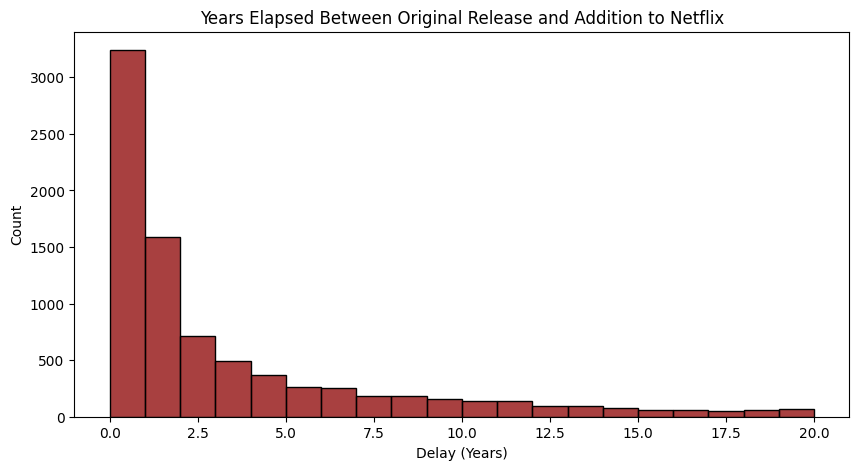

In [25]:
# Calculate delay in years
df['release_to_added_delay'] = df['added_year'] - df['release_year']

# Filter reasonable range (0 to 20 years delay)
plt.figure(figsize=(10, 5))
sns.histplot(df[df['release_to_added_delay'].between(0, 20)]['release_to_added_delay'], bins=20, color='darkred')
plt.title('Years Elapsed Between Original Release and Addition to Netflix')
plt.xlabel('Delay (Years)')
plt.show()

# summary statistics

In [26]:
# Summary statistics for numerical columns (release_year, added_year, delay, etc.)
df.describe()

,date_added,release_year,added_year,added_month,release_to_added_delay
count,8797,8807.000000,8797.000000,8797.000000,8797.000000
mean,2019-05-17 05:59:08.436967168,2014.180198,2018.871888,6.654996,4.688417
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000,-3.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000,0.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,7.000000,1.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,10.000000,5.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,93.000000
std,NaN,8.819312,1.574243,3.436554,8.786998


In [27]:
# Summary statistics for categorical columns (type, rating, country, director, etc.)
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description,added_month_name
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8797
unique,8807,2,8807,4529,7693,749,16,220,514,8775,12
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",July
freq,1,6131,1,2634,825,2818,3207,1793,362,4,827


In [28]:
movies['duration_min'].describe()

,duration_min
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [29]:
# Extract season counts for TV shows
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_433/1949278144.py:3: SyntaxWarning: invalid escape sequence '\d'
  tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)


In [30]:
# Summary of season counts
tv_shows['seasons'].describe()

,seasons
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


/tmp/ipykernel_433/94980553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


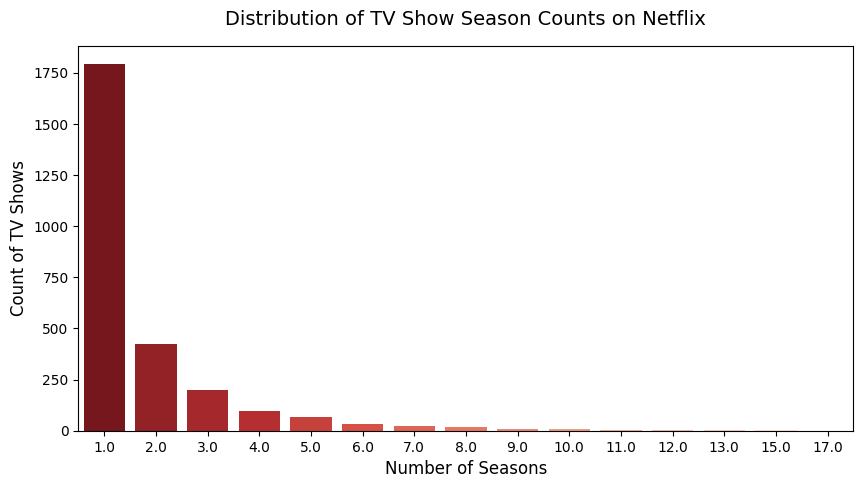

In [31]:
# Missing visual for TV Show Seasons (Cell [29])
plt.figure(figsize=(10, 5))
sns.countplot(
    data=tv_shows,
    x='seasons',
    palette='Reds_r'
)
plt.title('Distribution of TV Show Season Counts on Netflix', fontsize=14, pad=15)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Count of TV Shows', fontsize=12)
plt.show()

## Skewed / Non-Gaussian Metrics (Median & IQR)

### Columns like release_to_added_delay and release_year are heavily skewed (e.g., release_to_added_delay ranges from -3 to 93 years with a mean of 4.68 and median of 1.0). For skewed data, standard deviation and mean can be misleading.

In [32]:
# Median and IQR for delay
delay_median = df['release_to_added_delay'].median()
delay_iqr = df['release_to_added_delay'].quantile(0.75) - df['release_to_added_delay'].quantile(0.25)

print(f"Delay Median: {delay_median}, IQR: {delay_iqr}")

Delay Median: 1.0, IQR: 5.0


##Multi-Value Categorical Aggregations (Listed_in, Cast, Country)

### df.describe(include='object') treats comma-separated strings as single unique values. For example, it counts "Dramas, International Movies" as one category rather than breaking down individual genres or countries properly.

In [33]:
# Top 5 individual Genres
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(5)

# Top 5 individual Countries (excluding 'Unknown')
top_countries = df['country'].str.split(', ').explode()
top_countries = top_countries[top_countries != 'Unknown'].value_counts().head(5)

print("Top Genres:\n", top_genres)
print("\nTop Countries:\n", top_countries)

Top Genres:
 listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

Top Countries:
 country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64


/tmp/ipykernel_433/1226603263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_433/1226603263.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


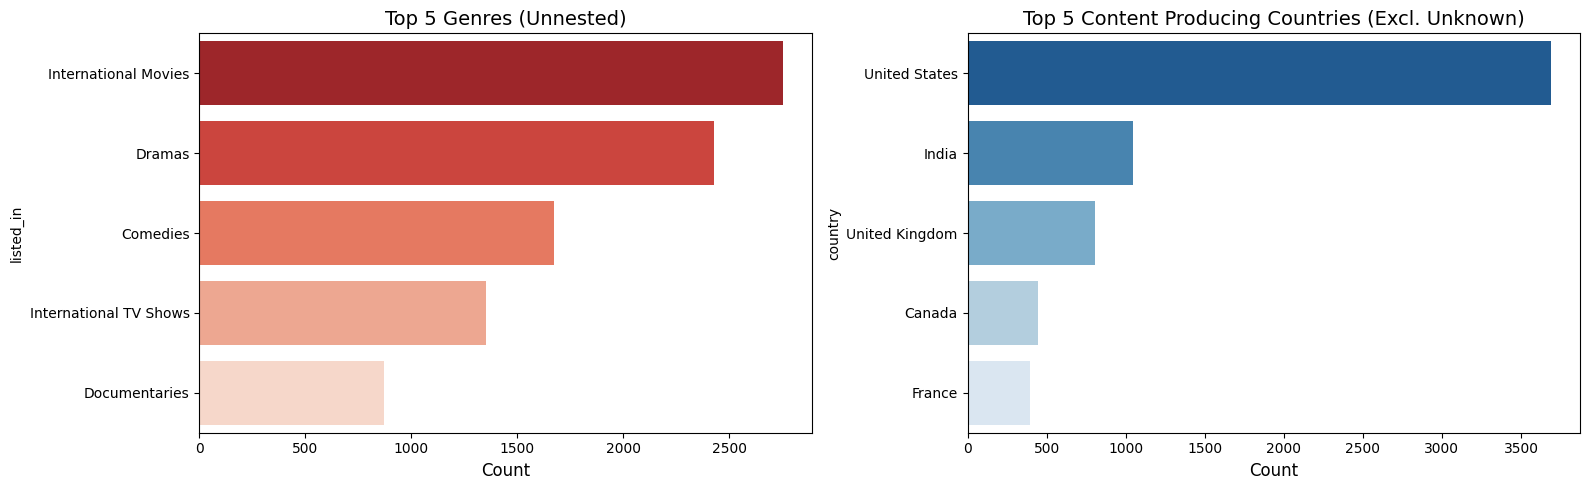

In [34]:
# Visuals for multi-value categorical summaries (Cell [31])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 5 Genres
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Top 5 Genres (Unnested)', fontsize=14)
axes[0].set_xlabel('Count', fontsize=12)

# Top 5 Countries
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    ax=axes[1],
    palette='Blues_r'
)
axes[1].set_title('Top 5 Content Producing Countries (Excl. Unknown)', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

## 1. Standard Numerical & Categorical Summaries

In [35]:
# 1. Standard Numerical & Categorical Summaries
print("--- Numerical Summary ---")
display(df.describe())

--- Numerical Summary ---


,date_added,release_year,added_year,added_month,release_to_added_delay
count,8797,8807.000000,8797.000000,8797.000000,8797.000000
mean,2019-05-17 05:59:08.436967168,2014.180198,2018.871888,6.654996,4.688417
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000,-3.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000,0.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,7.000000,1.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,10.000000,5.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,93.000000
std,NaN,8.819312,1.574243,3.436554,8.786998


In [36]:
print("\n--- Categorical Summary ---")
display(df.describe(include='object'))


--- Categorical Summary ---


,show_id,type,title,director,cast,country,rating,duration,listed_in,description,added_month_name
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8797
unique,8807,2,8807,4529,7693,749,16,220,514,8775,12
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",July
freq,1,6131,1,2634,825,2818,3207,1793,362,4,827


## 2. Extracted Numerical Summaries (Movie Minutes & TV Seasons)

In [37]:
print("\n--- Movie Duration (Minutes) Summary ---")
display(movies['duration_min'].describe())


--- Movie Duration (Minutes) Summary ---


,duration_min
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


In [38]:
print("\n--- TV Show Seasons Summary ---")
display(tv_shows['seasons'].describe())


--- TV Show Seasons Summary ---


,seasons
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


# corelation analysis

##1. Create numerical metrics for correlation

In [41]:
# 1. Feature engineering: Create the required numerical columns
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['num_cast_members'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(x.split(',')))
df['num_genres'] = df['listed_in'].apply(lambda x: len(x.split(',')))

# 2. Now run correlation safely
movie_corr = df[df['type'] == 'Movie'][['release_year', 'added_year', 'duration_num', 'num_cast_members', 'num_genres', 'release_to_added_delay']].corr()
tv_corr = df[df['type'] == 'TV Show'][['release_year', 'added_year', 'duration_num', 'num_cast_members', 'num_genres', 'release_to_added_delay']].corr()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_433/186486884.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


In [42]:
# Correlation specifically for Movies
movie_corr = df[df['type'] == 'Movie'][['release_year', 'added_year', 'duration_num', 'num_cast_members', 'num_genres', 'release_to_added_delay']].corr()

# Correlation specifically for TV Shows (seasons)
tv_corr = df[df['type'] == 'TV Show'][['release_year', 'added_year', 'duration_num', 'num_cast_members', 'num_genres', 'release_to_added_delay']].corr()


## 2. Compute correlation matrix on numerical features

In [43]:
corr_columns = ['release_year', 'added_year', 'duration_num', 'num_cast_members', 'num_genres', 'release_to_added_delay']
correlation_matrix = df[corr_columns].corr()

## 3. Plot Correlation Heatmap

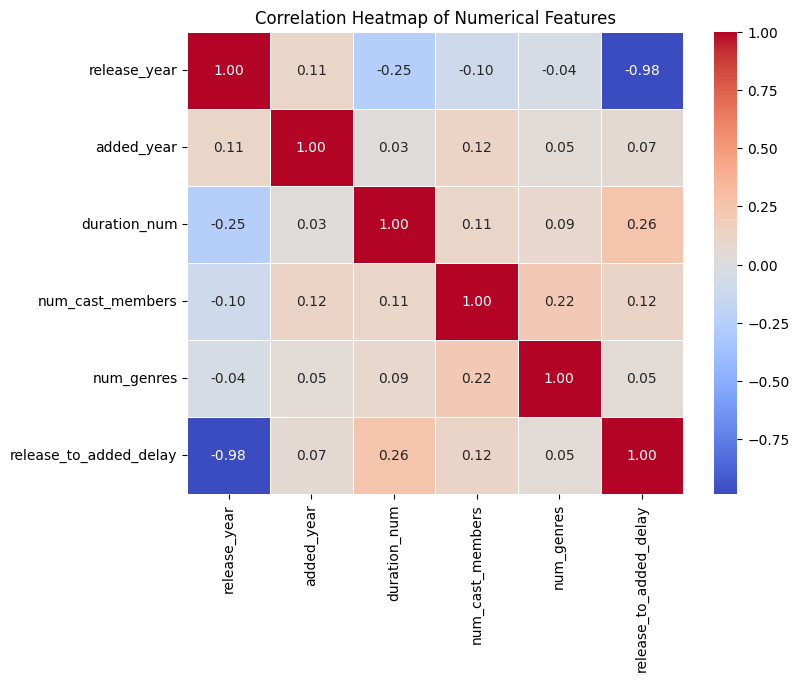

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_433/2081647178.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


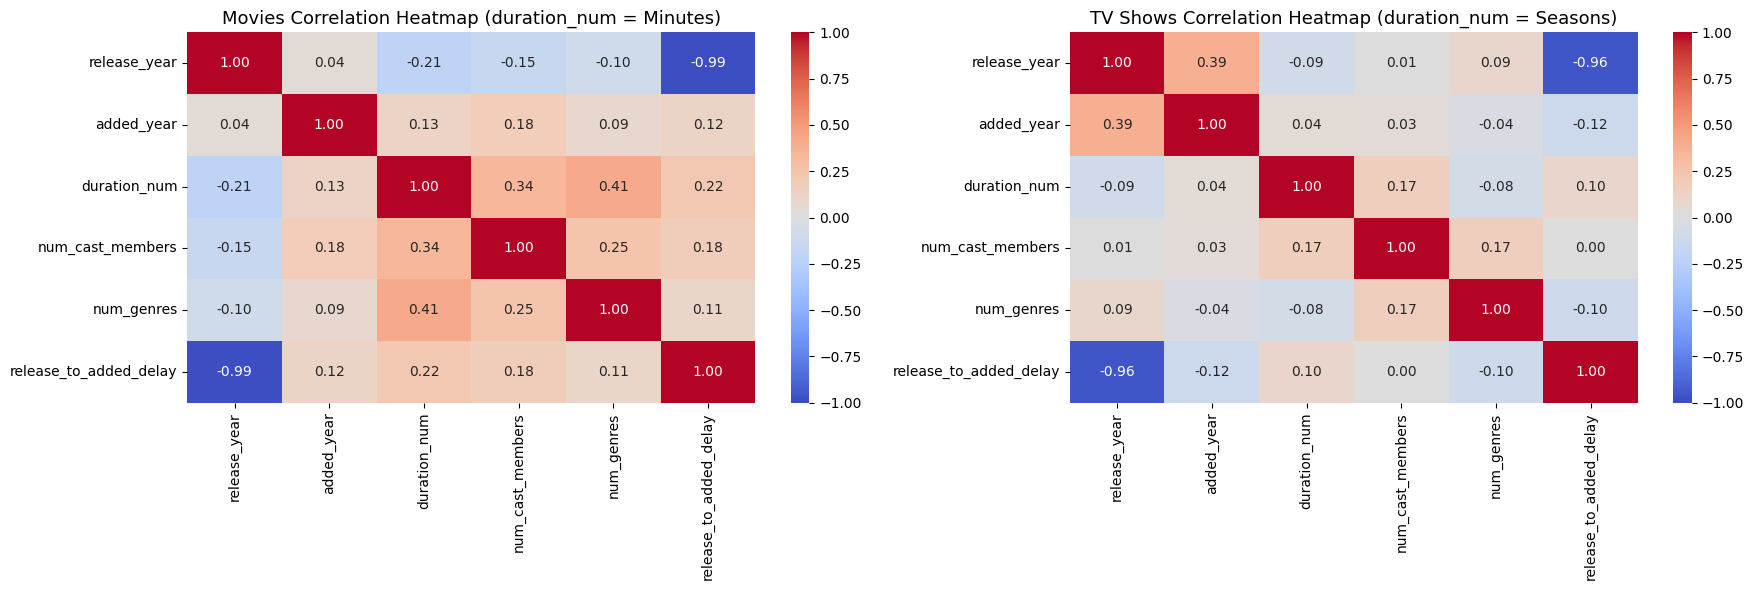

In [45]:
# 1. Ensuring numerical features exist in df
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['num_cast_members'] = df['cast'].apply(lambda x: 0 if x == 'Unknown' else len(str(x).split(', ')))
df['num_genres'] = df['listed_in'].apply(lambda x: len(str(x).split(', ')))

# 2. Compute separate correlation matrices
movie_corr = df[df['type'] == 'Movie'][[
    'release_year', 'added_year', 'duration_num',
    'num_cast_members', 'num_genres', 'release_to_added_delay'
]].corr()

tv_corr = df[df['type'] == 'TV Show'][[
    'release_year', 'added_year', 'duration_num',
    'num_cast_members', 'num_genres', 'release_to_added_delay'
]].corr()

# 3. Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(movie_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Movies Correlation Heatmap (duration_num = Minutes)', fontsize=13)

sns.heatmap(tv_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('TV Shows Correlation Heatmap (duration_num = Seasons)', fontsize=13)

plt.tight_layout()
plt.show()

## model building


In [46]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



In [58]:
#1
df = pd.read_csv('netflix_titles.csv.zip') # Save your preprocessed df to CSV

In [59]:
# 2. Combine textual features into a single metadata string
def combine_features(row):
    return f"{row['listed_in']} {row['description']} {row['director']} {row['cast']}"

In [60]:
df['combined_features'] = df.apply(combine_features, axis=1)

In [61]:
# 3. Compute TF-IDF Vector Matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

In [62]:
# 4. Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [63]:
# 5. Export processed artifacts for deployment
pickle.dump(df[['show_id', 'title', 'type', 'listed_in', 'description']], open('movies_dict.pkl', 'wb'))
pickle.dump(cosine_sim, open('similarity.pkl', 'wb'))
print("Model trained and artifacts saved successfully!")

Model trained and artifacts saved successfully!


In [64]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [65]:
!curl https://loca.lt/mytunnelpassword

35.221.164.88

In [66]:
!streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧your url is: https://little-actors-know.loca.lt
^C


In [68]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 54.8 MB/s eta 0:00:00


In [69]:
!streamlit run app.py & npx ssh -R 80:localhost:8501 free.pinggy.io

⠙⠹⠸⠼npm error could not determine executable to run
⠼npm error A complete log of this run can be found in: /root/.npm/_logs/2026-08-14T18_41_15_113Z-debug-0.log
⠼

2026-08-14 18:41:19.873 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.164.88:8501

  Stopping...


In [71]:
!streamlit run app.py & npx localtunnel --port 8501 --subdomain netflix-rec-demo

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://netflix-rec-demo.loca.lt
2026-08-14 18:43:28.530 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.164.88:8501

  Stopping...
^C


## Load the trained model and similarity matrix

In [72]:
import pickle

movies_dict = pickle.load(open('movies_dict.pkl', 'rb'))
cosine_sim = pickle.load(open('similarity.pkl', 'rb'))

print("Model artifacts loaded successfully!")

Model artifacts loaded successfully!


## Start the Streamlit application

In [73]:
!streamlit run app.py & npx localtunnel --port 8501 --subdomain netflix-rec-demo

⠙

⠹⠸⠼⠴⠦⠧2026-08-14 18:48:47.684 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.164.88:8501

your url is: https://netflix-rec-demo.loca.lt
  Stopping...
  Stopping...
^C


## Using ngrok for a more stable tunnel (Alternative to localtunnel)

In [78]:
# This cell was previously for ngrok installation. Removing content as per user's request.

In [79]:
# This cell was previously for ngrok authentication. Removing content as per user's request.

In [81]:
# Kill any running Streamlit processes to ensure a clean restart
!pkill -f streamlit

# Run Streamlit with more permissive settings in the background using nohup
# nohup ensures the process continues even if the shell session detaches.
# server.port=8501 explicitly sets the port Streamlit listens on.
print("Launching Streamlit app in the background...")
!nohup streamlit run app.py --server.enableCORS=True --server.enableXsrfProtection=False --server.port=8501 > streamlit.log 2>&1 &

# Give Streamlit a few seconds to start up before localtunnel connects
import time
print("Waiting for Streamlit to initialize (5 seconds)...")
time.sleep(5)

# Create a public tunnel using localtunnel
print("Creating public tunnel via localtunnel...")
!npx localtunnel --port 8501 --subdomain netflix-rec-demo

Launching Streamlit app in the background...
Waiting for Streamlit to initialize (5 seconds)...
Creating public tunnel via localtunnel...
⠙⠹⠸⠼your url is: https://netflix-rec-demo.loca.lt
^C
